# Requisito 2 - versione migliorata

Stesso ambiente, stessa istanza e stesso benchmark della versione base. Cambia solo il learner, in quattro punti:

1. per ogni arm stimo la probabilita' di vittoria p(win): a bid fissato, reward e costo dipendono solo dall'esito dell'asta, quindi basta una stima per arm invece di due;
2. l'intervallo di confidenza su p(win) usa il bound KL invece di Hoeffding;
3. nell'LP il costo e' quello empirico b*p_hat invece del costo LCB;
4. rho_t = budget residuo / round residui invece di B/T fisso, e l'LP considera solo le super-azioni ancora pagabili.

KL-UCB e' fuori dai lab: motivazione nel README, ablation in fondo. La baseline viene rieseguita qui sugli stessi seed per il confronto diretto.

## Modello

Identico alla versione base (marginali Beta con fattore comune, conflict graph, budget B).

In [61]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

SEED = 17
T = 3000
TRIALS = 20
B = 700.0
RHO = B / T

BID_GRID = np.linspace(0.0, 1.0, 11)
VALUES = np.array([0.95, 0.85, 0.78, 0.90])
CONFLICT_EDGES = [(0, 1), (1, 2), (2, 3)]
N_CAMPAIGNS = len(VALUES)

# marginali Beta del massimo bid concorrente, una per campagna
BETA_PARAMS = [(2.0, 5.0), (2.8, 3.8), (3.5, 3.0), (2.3, 4.0)]
# probabilita' che in un round tutte le campagne condividano lo stesso quantile
CORR_P = 0.3

np.set_printoptions(precision=3, suppress=True)
EPS = 1e-12

In [62]:
# arm atomici: coppie (campagna, bid) con 0 < bid <= v_i
ARM_CAMPAIGN, ARM_BID = [], []
for i in range(N_CAMPAIGNS):
    for b in BID_GRID:
        if 0.0 < b <= VALUES[i]:
            ARM_CAMPAIGN.append(i)
            ARM_BID.append(b)
ARM_CAMPAIGN = np.array(ARM_CAMPAIGN)
ARM_BID = np.array(ARM_BID)
N_ARMS = len(ARM_BID)
ARM_MAX_REWARD = VALUES[ARM_CAMPAIGN] - ARM_BID   # reward massimo dell'arm: vinta l'asta vale v - b

# super-azioni: un bid per campagna, nessuna coppia in conflitto attiva insieme
grids = [np.concatenate([[0.0], np.unique(ARM_BID[ARM_CAMPAIGN == i])]) for i in range(N_CAMPAIGNS)]
superactions = []
for bids in itertools.product(*grids):
    bids = np.array(bids)
    if any(bids[i] > 0 and bids[j] > 0 for i, j in CONFLICT_EDGES):
        continue
    superactions.append(bids)
SA_BIDS = np.array(superactions)
SA_BID_SUMS = SA_BIDS.sum(axis=1)
K = len(SA_BIDS)
NULL_IDX = 0
assert np.all(SA_BIDS[NULL_IDX] == 0)
MAX_SA_BID = float(SA_BID_SUMS.max())

# matrice di appartenenza super-azione -> arm atomici
SA_ARMS = np.zeros((K, N_ARMS))
for k in range(K):
    for a in range(N_ARMS):
        if SA_BIDS[k, ARM_CAMPAIGN[a]] == ARM_BID[a]:
            SA_ARMS[k, a] = 1.0

# medie vere degli arm dalla CDF Beta (le marginali non cambiano con la correlazione)
ARM_WIN_PROB = np.array([stats.beta.cdf(ARM_BID[a], *BETA_PARAMS[ARM_CAMPAIGN[a]]) for a in range(N_ARMS)])
TRUE_R = ARM_MAX_REWARD * ARM_WIN_PROB
TRUE_C = ARM_BID * ARM_WIN_PROB
SA_TRUE_R = SA_ARMS @ TRUE_R
SA_TRUE_C = SA_ARMS @ TRUE_C

print(f'arm atomici: {N_ARMS}, super-azioni ammissibili: {K}, costo massimo per round: {MAX_SA_BID:.2f}')

arm atomici: 33, super-azioni ammissibili: 250, costo massimo per round: 1.80


## Ambiente

correlazione empirica tra campagne:
[[1.   0.3  0.31 0.3 ]
 [0.3  1.   0.3  0.31]
 [0.31 0.3  1.   0.32]
 [0.3  0.31 0.32 1.  ]]


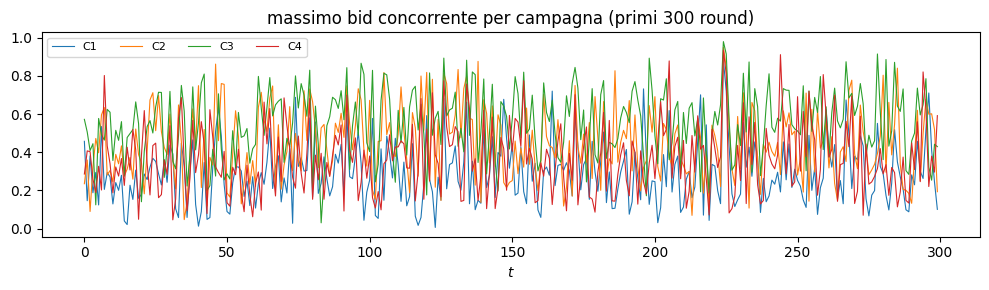

In [63]:
def build_thresholds(horizon, seed):
    # joint distribution: marginali Beta con un fattore comune.
    # In una frazione CORR_P dei round tutte le campagne usano lo stesso quantile u,
    # negli altri i quantili sono indipendenti. Le marginali restano Beta(a_i, b_i).
    rng = np.random.default_rng(seed)
    u = rng.uniform(size=(horizon, N_CAMPAIGNS))
    common = rng.uniform(size=horizon)
    shared = rng.uniform(size=horizon) < CORR_P
    u[shared] = common[shared, None]
    M = np.zeros_like(u)
    for i, (a, b) in enumerate(BETA_PARAMS):
        M[:, i] = stats.beta.ppf(u[:, i], a, b)
    return M


class MultiCampaignEnv:
    # una first-price auction per campagna per round, feedback semi-bandit
    def __init__(self, horizon, seed):
        self.M = build_thresholds(horizon, seed)
        self.t = 0

    def round(self, bids):
        m = self.M[self.t]
        self.t += 1
        wins = (bids >= m).astype(float)
        utilities = (VALUES - bids) * wins
        costs = bids * wins
        return wins, utilities, costs


Mst = build_thresholds(T, SEED)
fig, ax = plt.subplots(figsize=(10, 3))
for i in range(N_CAMPAIGNS):
    ax.plot(Mst[:300, i], lw=0.8, label=f'C{i+1}')
ax.set_title('massimo bid concorrente per campagna (primi 300 round)')
ax.set_xlabel('$t$'); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

corr = np.corrcoef(Mst.T)
print('correlazione empirica tra campagne:')
print(np.round(corr, 2))

## Clairvoyant

In [64]:
def solve_lp(scores, costs, rho, feasible=None):
    # LP sul simplesso delle super-azioni con vincolo di costo medio <= rho
    if feasible is None:
        feasible = np.ones(K, dtype=bool)
    bounds = [(0.0, 1.0) if feasible[k] else (0.0, 0.0) for k in range(K)]
    res = optimize.linprog(-scores, A_ub=[costs], b_ub=[max(rho, 0.0)],
                           A_eq=[np.ones(K)], b_eq=[1.0], bounds=bounds, method='highs')
    if (not res.success) or res.x is None:
        gamma = np.zeros(K); gamma[NULL_IDX] = 1.0
        return gamma
    gamma = np.clip(res.x, 0.0, None)
    if gamma.sum() <= 0:
        gamma = np.zeros(K); gamma[NULL_IDX] = 1.0
        return gamma
    return gamma / gamma.sum()


oracle_gamma = solve_lp(SA_TRUE_R, SA_TRUE_C, RHO)
ORACLE_REWARD = float(oracle_gamma @ SA_TRUE_R)
ORACLE_COST = float(oracle_gamma @ SA_TRUE_C)
print(f'oracle: reward atteso per round {ORACLE_REWARD:.4f}, costo atteso {ORACLE_COST:.4f}, rho = {RHO:.4f}')

oracle: reward atteso per round 0.5478, costo atteso 0.2333, rho = 0.2333


## Agenti

`CombUCBAgent` e' la baseline della versione base, rieseguita qui senza modifiche. `KLUCBPacingAgent` e' il learner migliorato; le due varianti servono solo per le ablation.

In [65]:
class RandomAgent:
    # baseline: super-azione uniforme tra quelle pagabili
    def __init__(self, budget, horizon, rng):
        self.budget = budget
        self.rng = rng
        self.k_t = NULL_IDX

    def act(self):
        affordable = np.flatnonzero(SA_BID_SUMS <= self.budget + EPS)
        self.k_t = NULL_IDX if affordable.size == 0 else int(self.rng.choice(affordable))
        return SA_BIDS[self.k_t]

    def update(self, wins, utilities, costs):
        self.budget = max(0.0, self.budget - costs.sum())


class ClairvoyantPolicy:
    # gioca la distribuzione dell'oracle (medie vere), serve da riferimento superiore
    def __init__(self, budget, horizon, rng):
        self.budget = budget
        self.rng = rng
        self.k_t = NULL_IDX

    def act(self):
        if self.budget < MAX_SA_BID:
            self.k_t = NULL_IDX
        else:
            self.k_t = int(self.rng.choice(K, p=oracle_gamma))
        return SA_BIDS[self.k_t]

    def update(self, wins, utilities, costs):
        self.budget = max(0.0, self.budget - costs.sum())


class CombUCBAgent:
    # Combinatorial-UCB con budget: medie empiriche per arm, reward UCB e costo LCB,
    # LP con rho = B/T fisso. I range dei bonus sono v-b per il reward e b per il costo.
    def __init__(self, budget, horizon, rng):
        self.budget = budget
        self.horizon = horizon
        self.rng = rng
        self.avg_f = np.zeros(N_ARMS)
        self.avg_c = np.zeros(N_ARMS)
        self.N_pulls = np.zeros(N_ARMS)
        self.k_t = NULL_IDX

    def act(self):
        if self.budget < MAX_SA_BID:      # stop quando anche il round peggiore non e' coperto
            self.k_t = NULL_IDX
            return SA_BIDS[NULL_IDX]
        bonus_f = ARM_MAX_REWARD * np.sqrt(2 * np.log(self.horizon) / np.maximum(self.N_pulls, 1))
        bonus_c = ARM_BID * np.sqrt(2 * np.log(self.horizon) / np.maximum(self.N_pulls, 1))
        f_ucb = self.avg_f + bonus_f
        c_lcb = np.maximum(self.avg_c - bonus_c, 0.0)
        never = self.N_pulls == 0
        f_ucb[never] = ARM_MAX_REWARD[never]   # arm mai giocato: reward al massimo, costo a zero
        c_lcb[never] = 0.0
        gamma = solve_lp(SA_ARMS @ f_ucb, SA_ARMS @ c_lcb, RHO)
        self.k_t = int(self.rng.choice(K, p=gamma))
        return SA_BIDS[self.k_t]

    def update(self, wins, utilities, costs):
        played = np.flatnonzero(SA_ARMS[self.k_t])
        for a in played:
            self.N_pulls[a] += 1
            i = ARM_CAMPAIGN[a]
            self.avg_f[a] += (utilities[i] - self.avg_f[a]) / self.N_pulls[a]
            self.avg_c[a] += (costs[i] - self.avg_c[a]) / self.N_pulls[a]
        self.budget = max(0.0, self.budget - costs.sum())

In [66]:
def bernoulli_kl(p, q):
    p = np.clip(p, EPS, 1 - EPS); q = np.clip(q, EPS, 1 - EPS)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))


def kl_confidence_bounds(p_hat, n_obs, t, n_iter=12):
    # intervallo KL su p(win); arm mai osservati restano con [0, 1]
    observed = n_obs > 0
    beta = np.log(max(t, 3))
    lo = np.zeros_like(p_hat); hi = p_hat.copy()
    for _ in range(n_iter):
        mid = (lo + hi) / 2
        ok = n_obs * bernoulli_kl(p_hat, mid) <= beta
        hi = np.where(ok & observed, mid, hi)
        lo = np.where((~ok) & observed, mid, lo)
    lower = np.where(observed, hi, 0.0)
    lo = p_hat.copy(); hi = np.ones_like(p_hat)
    for _ in range(n_iter):
        mid = (lo + hi) / 2
        ok = n_obs * bernoulli_kl(p_hat, mid) <= beta
        lo = np.where(ok & observed, mid, lo)
        hi = np.where((~ok) & observed, mid, hi)
    upper = np.where(observed, lo, 1.0)
    return lower, upper


def hoeffding_confidence_bounds(p_hat, n_obs, t):
    rad = np.sqrt(np.log(max(t, 3)) / (2 * np.maximum(n_obs, 1)))
    lower = np.where(n_obs > 0, np.clip(p_hat - rad, 0, 1), 0.0)
    upper = np.where(n_obs > 0, np.clip(p_hat + rad, 0, 1), 1.0)
    return lower, upper


class KLUCBPacingAgent:
    # learner migliorato: stima p(win) per arm, bound KL, costo empirico b*p_hat nell'LP,
    # rho_t = budget residuo / round residui, LP ristretto alle super-azioni pagabili
    bound = 'kl'
    cost_mode = 'empirical'

    def __init__(self, budget, horizon, rng):
        self.budget = budget
        self.horizon = horizon
        self.rng = rng
        self.n_obs = np.zeros(N_ARMS)
        self.n_wins = np.zeros(N_ARMS)
        self.t = 0
        self.k_t = NULL_IDX

    def act(self):
        affordable = SA_BID_SUMS <= self.budget + EPS
        if not np.any(affordable & (np.arange(K) != NULL_IDX)):
            self.k_t = NULL_IDX
            return SA_BIDS[NULL_IDX]
        p_hat = np.divide(self.n_wins, self.n_obs, out=np.zeros(N_ARMS), where=self.n_obs > 0)
        if self.bound == 'kl':
            p_lcb, p_ucb = kl_confidence_bounds(p_hat, self.n_obs, self.t + 1)
        else:
            p_lcb, p_ucb = hoeffding_confidence_bounds(p_hat, self.n_obs, self.t + 1)
        f_ucb = ARM_MAX_REWARD * p_ucb
        cost_est = ARM_BID * (p_hat if self.cost_mode == 'empirical' else p_lcb)
        rho_t = max(self.budget, 0.0) / max(1, self.horizon - self.t)
        gamma = solve_lp(SA_ARMS @ f_ucb, SA_ARMS @ cost_est, rho_t, feasible=affordable)
        self.k_t = int(self.rng.choice(K, p=gamma))
        return SA_BIDS[self.k_t]

    def update(self, wins, utilities, costs):
        played = np.flatnonzero(SA_ARMS[self.k_t])
        for a in played:
            self.n_obs[a] += 1
            self.n_wins[a] += wins[ARM_CAMPAIGN[a]]
        self.budget = max(0.0, self.budget - costs.sum())
        self.t += 1


class HoeffdingVariant(KLUCBPacingAgent):
    # ablation: bound di Hoeffding al posto del KL
    bound = 'hoeffding'


class LCBCostVariant(KLUCBPacingAgent):
    # ablation: costo LCB al posto del costo empirico
    cost_mode = 'lcb'


## Simulazione

Stesso protocollo della versione base: 20 trial appaiati, pseudo-regret contro l'oracle come metrica principale.

In [67]:
def run_trial(agent_cls, seed):
    env = MultiCampaignEnv(T, seed)
    agent = agent_cls(B, T, np.random.default_rng(seed + 1_000))
    exp_rewards = np.zeros(T)
    rewards = np.zeros(T)
    costs = np.zeros(T)
    selected = np.zeros(T, dtype=int)
    for t in range(T):
        bids = agent.act()
        wins, utilities, cost_vec = env.round(bids)
        agent.update(wins, utilities, cost_vec)
        exp_rewards[t] = SA_TRUE_R[agent.k_t]
        rewards[t] = utilities.sum()
        costs[t] = cost_vec.sum()
        selected[t] = agent.k_t
    return {'agent': agent,
            'pseudo_regret': np.cumsum(ORACLE_REWARD - exp_rewards),
            'realized_regret': np.cumsum(ORACLE_REWARD - rewards),
            'cum_cost': np.cumsum(costs),
            'reward_total': rewards.sum(),
            'selected': selected}


def mean_sem(curves):
    m = np.vstack(curves)
    return m.mean(axis=0), m.std(axis=0, ddof=1) / np.sqrt(m.shape[0])


def summarize(name, runs):
    pseudo = np.vstack([r['pseudo_regret'] for r in runs])
    realized = np.vstack([r['realized_regret'] for r in runs])
    spend = np.array([r['cum_cost'][-1] for r in runs])
    cps = [T // 4 - 1, T // 2 - 1, 3 * T // 4 - 1, T - 1]
    mp = pseudo.mean(axis=0)
    return {'agent': name,
            'reward_totale': float(np.mean([r['reward_total'] for r in runs])),
            'pct_oracle': 100 * float(np.mean([r['reward_total'] for r in runs])) / (ORACLE_REWARD * T),
            'spesa': float(spend.mean()),
            'pseudo_regret_finale': float(mp[-1]),
            'realized_regret_finale': float(realized.mean(axis=0)[-1]),
            'pseudo_Rt_su_t': [round(float(mp[c] / (c + 1)), 4) for c in cps]}

In [68]:
random_runs, clair_runs, lab_runs, ucb_runs = [], [], [], []
for i in range(TRIALS):
    random_runs.append(run_trial(RandomAgent, 100 + i))
    clair_runs.append(run_trial(ClairvoyantPolicy, 100 + i))
    lab_runs.append(run_trial(CombUCBAgent, 100 + i))
    ucb_runs.append(run_trial(KLUCBPacingAgent, 100 + i))

summary = pd.DataFrame([summarize('Random', random_runs),
                        summarize('Clairvoyant policy', clair_runs),
                        summarize('C-UCB base', lab_runs),
                        summarize('KL-UCB migliorato', ucb_runs)])
summary

,agent,reward_totale,pct_oracle,spesa,pseudo_regret_finale,realized_regret_finale,pseudo_Rt_su_t
0,Random,341.0075,20.748400,700.000,1305.557836,1302.528872,"[0.2159, 0.3225, 0.3976, 0.4352]"
1,Clairvoyant policy,1628.9350,99.111588,693.450,11.802113,14.601372,"[0.0, 0.0001, -0.0, 0.0039]"
2,C-UCB base,1047.2180,63.717361,698.575,595.154806,596.318372,"[0.0385, -0.0033, 0.0819, 0.1984]"
3,KL-UCB migliorato,1570.4475,95.552951,699.835,70.054544,73.088872,"[0.05, 0.0349, 0.0275, 0.0234]"


## Confronto con la baseline, stesso ambiente

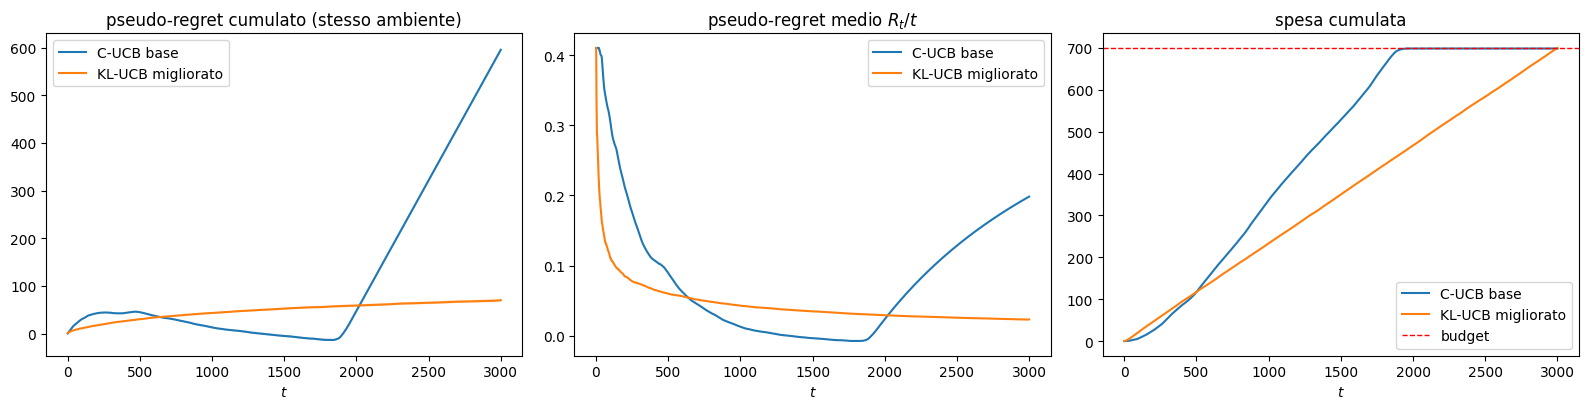

In [69]:
x = np.arange(1, T + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for name, runs in [('C-UCB base', lab_runs), ('KL-UCB migliorato', ucb_runs)]:
    m, sem = mean_sem([r['pseudo_regret'] for r in runs])
    axes[0].plot(x, m, label=name)
    axes[0].fill_between(x, m - sem, m + sem, alpha=0.2)
    axes[1].plot(x, m / x, label=name)
    mc, _ = mean_sem([r['cum_cost'] for r in runs])
    axes[2].plot(x, mc, label=name)
axes[0].set_title('pseudo-regret cumulato (stesso ambiente)'); axes[0].set_xlabel('$t$'); axes[0].legend()
axes[1].set_title('pseudo-regret medio $R_t/t$'); axes[1].set_xlabel('$t$'); axes[1].legend()
axes[2].axhline(B, color='red', ls='--', lw=1, label='budget')
axes[2].set_title('spesa cumulata'); axes[2].set_xlabel('$t$'); axes[2].legend()
plt.tight_layout(); plt.show()

## Ablation

Cambio un pezzo alla volta per capire da dove viene il miglioramento.

pseudo-regret finale  KL: 70.1   Hoeffding: 100.5


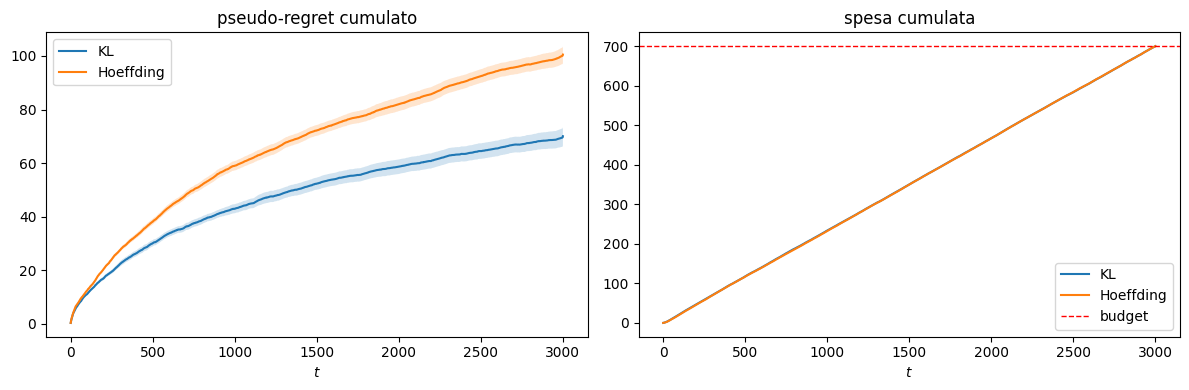

In [70]:
# ablation 1: KL contro Hoeffding su p(win), tutto il resto uguale
hoeff_runs = []
for i in range(TRIALS):
    hoeff_runs.append(run_trial(HoeffdingVariant, 100 + i))

kl_mean, kl_sem = mean_sem([r['pseudo_regret'] for r in ucb_runs])
ho_mean, ho_sem = mean_sem([r['pseudo_regret'] for r in hoeff_runs])
kl_cost, _ = mean_sem([r['cum_cost'] for r in ucb_runs])
ho_cost, _ = mean_sem([r['cum_cost'] for r in hoeff_runs])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x, kl_mean, label='KL'); ax[0].fill_between(x, kl_mean - kl_sem, kl_mean + kl_sem, alpha=0.2)
ax[0].plot(x, ho_mean, label='Hoeffding'); ax[0].fill_between(x, ho_mean - ho_sem, ho_mean + ho_sem, alpha=0.2)
ax[0].set_title('pseudo-regret cumulato'); ax[0].set_xlabel('$t$'); ax[0].legend()
ax[1].plot(x, kl_cost, label='KL'); ax[1].plot(x, ho_cost, label='Hoeffding')
ax[1].axhline(B, color='red', ls='--', lw=1, label='budget')
ax[1].set_title('spesa cumulata'); ax[1].set_xlabel('$t$'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f'pseudo-regret finale  KL: {kl_mean[-1]:.1f}   Hoeffding: {ho_mean[-1]:.1f}')

pseudo-regret finale  empirico: 70.1   LCB: 166.2
spesa a T/4           empirico: 176.0   LCB: 241.4


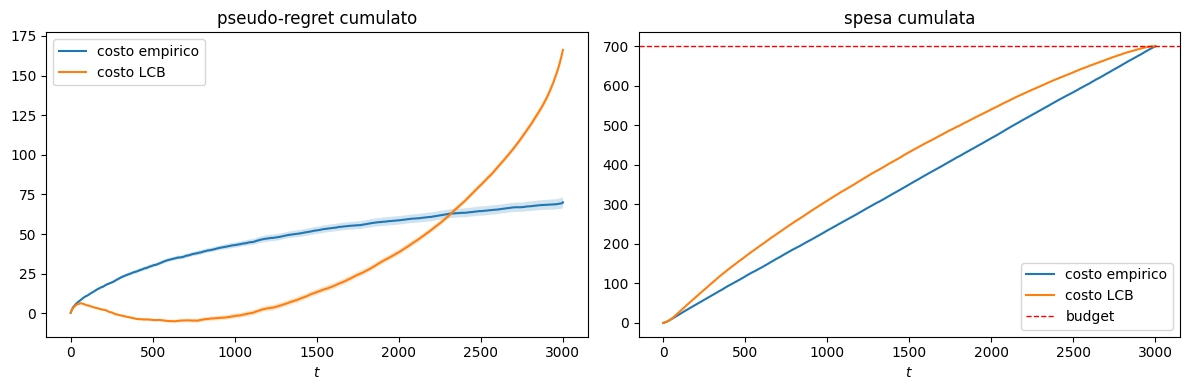

In [71]:
# ablation 2: costo empirico contro costo LCB, tutto il resto uguale
lcb_runs = []
for i in range(TRIALS):
    lcb_runs.append(run_trial(LCBCostVariant, 100 + i))

emp_mean, emp_sem = mean_sem([r['pseudo_regret'] for r in ucb_runs])
lcb_mean, lcb_sem = mean_sem([r['pseudo_regret'] for r in lcb_runs])
emp_cost, _ = mean_sem([r['cum_cost'] for r in ucb_runs])
lcb_cost, _ = mean_sem([r['cum_cost'] for r in lcb_runs])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x, emp_mean, label='costo empirico'); ax[0].fill_between(x, emp_mean - emp_sem, emp_mean + emp_sem, alpha=0.2)
ax[0].plot(x, lcb_mean, label='costo LCB'); ax[0].fill_between(x, lcb_mean - lcb_sem, lcb_mean + lcb_sem, alpha=0.2)
ax[0].set_title('pseudo-regret cumulato'); ax[0].set_xlabel('$t$'); ax[0].legend()
ax[1].plot(x, emp_cost, label='costo empirico'); ax[1].plot(x, lcb_cost, label='costo LCB')
ax[1].axhline(B, color='red', ls='--', lw=1, label='budget')
ax[1].set_title('spesa cumulata'); ax[1].set_xlabel('$t$'); ax[1].legend()
plt.tight_layout(); plt.show()
q = T // 4 - 1
print(f'pseudo-regret finale  empirico: {emp_mean[-1]:.1f}   LCB: {lcb_mean[-1]:.1f}')
print(f'spesa a T/4           empirico: {emp_cost[q]:.1f}   LCB: {lcb_cost[q]:.1f}')

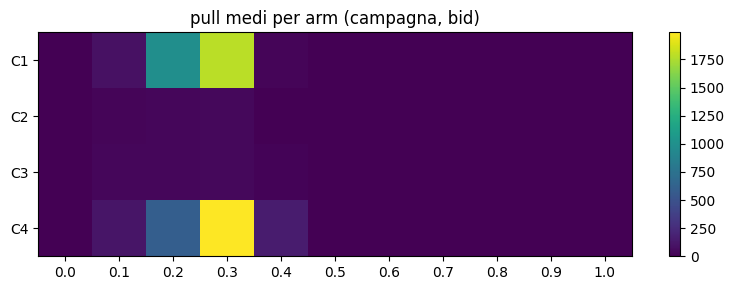

In [72]:
# numero medio di pull per arm (media sui trial)
pulls = np.zeros((N_CAMPAIGNS, len(BID_GRID)))
counts = np.zeros_like(pulls)
attr = 'N_pulls' if hasattr(ucb_runs[0]['agent'], 'N_pulls') else 'n_obs'
for r in ucb_runs:
    ag = r['agent']
    n = getattr(ag, attr)
    for a in range(N_ARMS):
        j = int(round(ARM_BID[a] * 10))
        pulls[ARM_CAMPAIGN[a], j] += n[a] / TRIALS

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(pulls, aspect='auto')
ax.set_xticks(range(len(BID_GRID))); ax.set_xticklabels([f'{b:.1f}' for b in BID_GRID])
ax.set_yticks(range(N_CAMPAIGNS)); ax.set_yticklabels([f'C{i+1}' for i in range(N_CAMPAIGNS)])
ax.set_title('pull medi per arm (campagna, bid)')
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## Lettura del risultato

Sulle stesse realizzazioni dell'ambiente, il learner migliorato chiude con pseudo-regret ~70 contro ~595 della baseline, con Rt/t che scende fino a ~0.023 e continua a calare; la spesa segue il budget fino in fondo senza mai violarlo.

Le ablation separano i contributi. Costo empirico contro costo LCB: 70 contro 166 di pseudo-regret, e a T/4 il LCB ha gia' speso 241 contro 176 - e' la conferma che il problema della baseline era la spesa troppo veloce, non le stime dei reward. KL contro Hoeffding su p(win): 70 contro 100 - il bound KL aiuta perche' molti arm hanno probabilita' di vittoria piccole, dove Hoeffding resta largo. Il pacing dinamico e il filtro sulle super-azioni pagabili completano il quadro facendo arrivare la spesa esattamente a fine orizzonte.